## Imports og tilkobling

In [2]:
import sys
import os
import pandas as pd
import io
from dotenv import load_dotenv
from azure.storage.blob import BlobServiceClient

sys.path.append(os.path.abspath("../../../"))
from src.feature_engineering.forbruksdata import create_consumption_features

load_dotenv()

connection_string = os.getenv("AZURE_STORAGE_CONNECTION_STRING")

blob_service_client = BlobServiceClient.from_connection_string(connection_string)
container_name = "rawdata"

## Hente CSV fra blob

In [3]:
blob_name = "HARTEVATN.csv"

blob_client = blob_service_client.get_blob_client(
    container=container_name,
    blob=blob_name
)

data = blob_client.download_blob().readall()

df = pd.read_csv(io.BytesIO(data))

## Feature engineering

In [4]:
# feature engineering
df = create_consumption_features(df)

# se resultat
df.head()

,metering_point_anonymous,timestamp,value_kwh,transformer_station,consumption_code,hour,weekday,month,is_weekend,is_holiday,day_night,norgespris
0,4c22dc3e-ce91-4275-9dfd-22ce2f386072,2025-12-25 23:00:00,1.34,HARTEVATN,36,23,3,12,False,False,night,1
1,4c22dc3e-ce91-4275-9dfd-22ce2f386072,2025-12-26 00:00:00,1.57,HARTEVATN,36,0,4,12,False,False,night,1
2,4c22dc3e-ce91-4275-9dfd-22ce2f386072,2025-12-26 01:00:00,1.22,HARTEVATN,36,1,4,12,False,False,night,1
3,4c22dc3e-ce91-4275-9dfd-22ce2f386072,2025-12-26 02:00:00,1.45,HARTEVATN,36,2,4,12,False,False,night,1
4,4c22dc3e-ce91-4275-9dfd-22ce2f386072,2025-12-26 03:00:00,1.56,HARTEVATN,36,3,4,12,False,False,night,1


## Legge til blob

In [4]:
import io

# --- Lag CSV i minnet ---
csv_buffer = io.BytesIO()
df.to_csv(csv_buffer, index=False)
csv_buffer.seek(0)  # gå til starten av bufferet

# --- Last opp til blob ---
container_name = "processeddata"
output_blob_name = "HARTEVATN_processed.csv" 
blob_client = blob_service_client.get_blob_client(container=container_name, blob=output_blob_name)
blob_client.upload_blob(csv_buffer, overwrite=True)  # overwrite=True overskriver eksisterende fil

print(f"{output_blob_name} lastet opp til blob!")

HARTEVATN_processed.csv lastet opp til blob!


# Kvalitetssikring

## Forbruksverdier

In [18]:
df.groupby("consumption_code")["value_kwh"].max()

consumption_code
26    18.0
35    35.5
36    72.0
Name: value_kwh, dtype: float64

In [19]:
# Ekstreme verdier
threshold = df["value_kwh"].quantile(0.999)

df[df["value_kwh"] > threshold].sort_values("value_kwh", ascending=False).head(10)

,metering_point_anonymous,timestamp,value_kwh,transformer_station,consumption_code,hour,weekday,month,is_weekend,is_holiday,day_night,norgespris,hour_check,weekday_check,month_check,is_weekend_check,day_night_check
7851497,d3aaaaa0-6ce5-4411-9a65-d2efd2dbd93d,2025-12-29 18:00:00,72.0,HARTEVATN,36,18,0,12,False,False,day,1,18,0,12,False,day
9236355,d3aaaaa0-6ce5-4411-9a65-d2efd2dbd93d,2025-12-30 10:00:00,69.0,HARTEVATN,36,10,1,12,False,False,day,1,10,1,12,False,day
9236353,d3aaaaa0-6ce5-4411-9a65-d2efd2dbd93d,2025-12-30 08:00:00,69.0,HARTEVATN,36,8,1,12,False,False,day,1,8,1,12,False,day
7851495,d3aaaaa0-6ce5-4411-9a65-d2efd2dbd93d,2025-12-29 16:00:00,66.0,HARTEVATN,36,16,0,12,False,False,day,1,16,0,12,False,day
6986120,d3aaaaa0-6ce5-4411-9a65-d2efd2dbd93d,2025-12-31 17:00:00,66.0,HARTEVATN,36,17,2,12,False,True,day,1,17,2,12,False,day
21331,d3aaaaa0-6ce5-4411-9a65-d2efd2dbd93d,2026-01-08 18:00:00,63.0,HARTEVATN,36,18,3,1,False,False,day,1,18,3,1,False,day
7303160,d3aaaaa0-6ce5-4411-9a65-d2efd2dbd93d,2025-01-03 18:00:00,63.0,HARTEVATN,36,18,4,1,False,False,day,0,18,4,1,False,day
7851496,d3aaaaa0-6ce5-4411-9a65-d2efd2dbd93d,2025-12-29 17:00:00,63.0,HARTEVATN,36,17,0,12,False,False,day,1,17,0,12,False,day
2270501,d3aaaaa0-6ce5-4411-9a65-d2efd2dbd93d,2026-01-29 08:00:00,63.0,HARTEVATN,36,8,3,1,False,False,day,1,8,3,1,False,day
8080221,d3aaaaa0-6ce5-4411-9a65-d2efd2dbd93d,2026-01-09 19:00:00,63.0,HARTEVATN,36,19,4,1,False,False,day,1,19,4,1,False,day


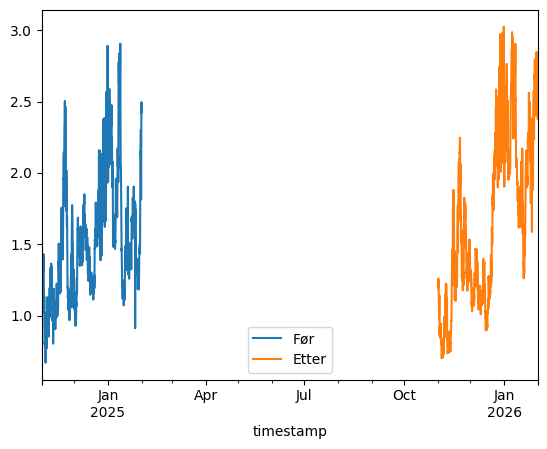

In [ ]:
# Graf
before = df[df["norgespris"] == 0].groupby("timestamp")["value_kwh"].mean()
after = df[df["norgespris"] == 1].groupby("timestamp")["value_kwh"].mean()

import matplotlib.pyplot as plt

before.plot(label="Før")
after.plot(label="Etter")

plt.legend()
plt.show()

## Duplikater per id + timestamp

In [8]:
duplicates = df.duplicated(
    subset=["metering_point_anonymous", "timestamp"],
    keep=False
)

df[duplicates]

,metering_point_anonymous,timestamp,value_kwh,transformer_station,consumption_code,hour,weekday,month,is_weekend,is_holiday,day_night,norgespris


In [9]:
df.duplicated(
    subset=["metering_point_anonymous", "timestamp"]
).sum()

np.int64(0)

## Feature engineering

In [10]:
# hour, weekday, month
df["hour_check"] = df["timestamp"].dt.hour
df["weekday_check"] = df["timestamp"].dt.weekday
df["month_check"] = df["timestamp"].dt.month

df[
    (df["hour"] != df["hour_check"]) |
    (df["weekday"] != df["weekday_check"]) |
    (df["month"] != df["month_check"])
]

,metering_point_anonymous,timestamp,value_kwh,transformer_station,consumption_code,hour,weekday,month,is_weekend,is_holiday,day_night,norgespris,hour_check,weekday_check,month_check


In [11]:
# is_weekend
df["is_weekend_check"] = df["timestamp"].dt.weekday >= 5

df[df["is_weekend"] != df["is_weekend_check"]]

,metering_point_anonymous,timestamp,value_kwh,transformer_station,consumption_code,hour,weekday,month,is_weekend,is_holiday,day_night,norgespris,hour_check,weekday_check,month_check,is_weekend_check


In [12]:
# is_holiday
df[df["is_holiday"] == True]["timestamp"].dt.date.unique()

array([datetime.date(2024, 12, 31), datetime.date(2025, 12, 31),
       datetime.date(2024, 12, 24), datetime.date(2025, 12, 24)],
      dtype=object)

In [13]:
# day_night
df["day_night_check"] = df["timestamp"].dt.hour.apply(
    lambda x: "day" if 6 <= x < 22 else "night"
)

df[df["day_night"] != df["day_night_check"]]

,metering_point_anonymous,timestamp,value_kwh,transformer_station,consumption_code,hour,weekday,month,is_weekend,is_holiday,day_night,norgespris,hour_check,weekday_check,month_check,is_weekend_check,day_night_check


## Norgespris

In [14]:
# Sjekk perioder
df.groupby("norgespris")["timestamp"].agg(["min", "max"])

,min,max
norgespris,,
0,2024-11-01,2025-01-31 23:00:00
1,2025-11-01,2026-01-31 23:00:00


In [15]:
# Sjekke for null-verdier
df["norgespris"].value_counts(dropna=False)

norgespris
1    4844352
0    4844352
Name: count, dtype: int64

## Datakvalitets rapport

In [16]:
def data_quality_report(df):
    print("=== GENERELT ===")
    print("Antall rader:", len(df))
    print("Antall unike ID-er:", df["metering_point_anonymous"].nunique())
    
    print("\n=== MISSING VALUES ===")
    print(df.isna().sum())

    print("\n=== DUPLIKATER (ID + timestamp) ===")
    dup = df.duplicated(subset=["metering_point_anonymous", "timestamp"]).sum()
    print("Antall duplikater:", dup)

    print("\n=== FORBRUK ===")
    print("Negative verdier:", (df["value_kwh"] < 0).sum())
    print("Nullverdier:", (df["value_kwh"] == 0).sum())
    
    print("\nPercentiler:")
    print(df["value_kwh"].quantile([0.5, 0.9, 0.99, 0.999]))

    print("\n=== EKSTREME VERDIER (TOP 5) ===")
    print(df.nlargest(5, "value_kwh")[["metering_point_anonymous", "timestamp", "value_kwh"]])

    print("\n=== TIDSSERIE (PER ID) ===")
    df_sorted = df.sort_values(["metering_point_anonymous", "timestamp"])
    df_sorted["diff"] = df_sorted.groupby("metering_point_anonymous")["timestamp"].diff()
    
    wrong_diff = (df_sorted["diff"] != pd.Timedelta(hours=1)).sum()
    print("Avvik fra 1 time intervall:", wrong_diff)

    print("\n=== FEATURE ENGINEERING ===")
    errors = 0
    
    errors += (df["hour"] != df["timestamp"].dt.hour).sum()
    errors += (df["weekday"] != df["timestamp"].dt.weekday).sum()
    errors += (df["month"] != df["timestamp"].dt.month).sum()
    
    weekend_check = df["timestamp"].dt.weekday >= 5
    errors += (df["is_weekend"] != weekend_check).sum()

    print("Antall avvik i features:", errors)

    print("\n=== HOLIDAYS ===")
    holiday_dates = df[df["is_holiday"] == True]["timestamp"].dt.date.unique()
    print("Antall unike holiday-datoer:", len(holiday_dates))

    print("\n=== NORGESPRIS ===")
    print(df["norgespris"].value_counts(dropna=False))

    print("\nPerioder per norgespris:")
    print(df.groupby("norgespris")["timestamp"].agg(["min", "max"]))

    outside = df[~df["norgespris"].isin([0, 1])]
    print("\nObservasjoner utenfor perioder:", len(outside))

    print("\n=== SAMMENLIGNBARHET ===")
    print("Observasjoner per periode:")
    print(df["norgespris"].value_counts())

    print("\nUnike ID-er per periode:")
    print(df.groupby("norgespris")["metering_point_anonymous"].nunique())

    print("\nSnitt forbruk per periode:")
    print(df.groupby("norgespris")["value_kwh"].mean())

In [17]:
data_quality_report(df)

=== GENERELT ===
Antall rader: 9688704
Antall unike ID-er: 2194

=== MISSING VALUES ===
metering_point_anonymous    0
timestamp                   0
value_kwh                   0
transformer_station         0
consumption_code            0
hour                        0
weekday                     0
month                       0
is_weekend                  0
is_holiday                  0
day_night                   0
norgespris                  0
hour_check                  0
weekday_check               0
month_check                 0
is_weekend_check            0
day_night_check             0
dtype: int64

=== DUPLIKATER (ID + timestamp) ===
Antall duplikater: 0

=== FORBRUK ===
Negative verdier: 0
Nullverdier: 244185

Percentiler:
0.500     1.17
0.900     3.41
0.990     7.88
0.999    16.14
Name: value_kwh, dtype: float64

=== EKSTREME VERDIER (TOP 5) ===
                     metering_point_anonymous           timestamp  value_kwh
7851497  d3aaaaa0-6ce5-4411-9a65-d2efd2dbd93d 2025-12-29 